In [1]:
import pandas as pd

df = pd.read_csv("../data/insurance_data.csv")

df.head()

,CustomerID,Age,Gender,Province,VehicleType,AnnualIncome,RiskScore,AnnualPremium,Deductible,NCD,...,Claimed,ClaimAmount,TotalPremium,TotalClaims,CoverType,AutoMake,VehicleModel,CustomValueEstimate,ZipCode,TransactionDate
0,AC-100000,56,Male,Addis Ababa,Sedan,147270,61,2346,500,30,...,False,0.0,2346,0.0,Comprehensive,Lifan,620,32238,10002,2024-05-10
1,AC-100001,69,Female,Addis Ababa,SUV,74640,57,2334,500,0,...,True,9883.0,2334,9883.0,Comprehensive,Suzuki,Grand Vitara,52510,10001,2024-08-13
2,AC-100002,46,Male,Oromia,Sedan,70555,42,1697,250,20,...,False,0.0,1697,0.0,Third Party Fire & Theft,Lifan,620,26523,20001,2025-03-17
3,AC-100003,32,Female,Somali,Sedan,89398,63,2370,500,20,...,True,12134.0,2370,12134.0,Comprehensive,Toyota,Corolla,27036,40005,2025-03-17
4,AC-100004,60,Female,Tigray,SUV,78475,69,2582,500,0,...,False,0.0,2582,0.0,Comprehensive,Toyota,RAV4,58348,50002,2024-11-10


In [2]:
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           10000 non-null  str    
 1   Age                  10000 non-null  int64  
 2   Gender               10000 non-null  str    
 3   Province             10000 non-null  str    
 4   VehicleType          10000 non-null  str    
 5   AnnualIncome         10000 non-null  int64  
 6   RiskScore            10000 non-null  int64  
 7   AnnualPremium        10000 non-null  int64  
 8   Deductible           10000 non-null  int64  
 9   NCD                  10000 non-null  int64  
 10  PastClaims           10000 non-null  int64  
 11  Claimed              10000 non-null  bool   
 12  ClaimAmount          10000 non-null  float64
 13  TotalPremium         10000 non-null  int64  
 14  TotalClaims          10000 non-null  float64
 15  CoverType            10000 non-null  str    
 16

,Age,AnnualIncome,RiskScore,AnnualPremium,Deductible,NCD,PastClaims,ClaimAmount,TotalPremium,TotalClaims,CustomValueEstimate,ZipCode
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,46.683500,79201.97390,58.140000,2488.127900,751.700000,20.935000,1.064200,1314.188500,2488.127900,1314.188500,35640.598700,23215.00050
std,16.717963,33039.93977,14.267486,735.674491,500.509401,14.549122,1.051945,3921.864903,735.674491,3921.864903,22353.988238,12848.33245
min,18.000000,17202.00000,15.000000,951.000000,250.000000,0.000000,0.000000,0.000000,951.000000,0.000000,5022.000000,10001.00000
25%,32.000000,56105.00000,48.000000,2028.000000,500.000000,10.000000,0.000000,0.000000,2028.000000,0.000000,21442.750000,10004.00000
50%,46.000000,72942.00000,57.000000,2307.000000,500.000000,20.000000,1.000000,0.000000,2307.000000,0.000000,28522.000000,20003.00000
75%,61.000000,95092.00000,67.000000,2676.000000,1000.000000,30.000000,2.000000,0.000000,2676.000000,0.000000,46721.000000,30004.00000
max,75.000000,376916.00000,95.000000,5105.000000,2000.000000,50.000000,5.000000,49623.000000,5105.000000,49623.000000,134914.000000,50005.00000


In [3]:
df.isnull().sum()

CustomerID             0
Age                    0
Gender                 0
Province               0
VehicleType            0
AnnualIncome           0
RiskScore              0
AnnualPremium          0
Deductible             0
NCD                    0
PastClaims             0
Claimed                0
ClaimAmount            0
TotalPremium           0
TotalClaims            0
CoverType              0
AutoMake               0
VehicleModel           0
CustomValueEstimate    0
ZipCode                0
TransactionDate        0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df["LossRatio"] = df["TotalClaims"] / df["TotalPremium"]

df["Margin"] = df["TotalPremium"] - df["TotalClaims"]

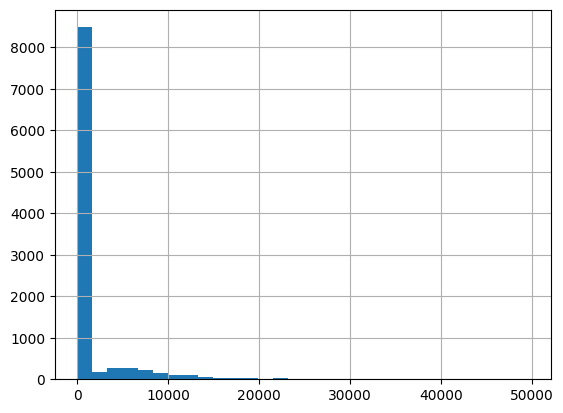

In [6]:
import matplotlib.pyplot as plt

df["TotalClaims"].hist(bins=30)
plt.show()

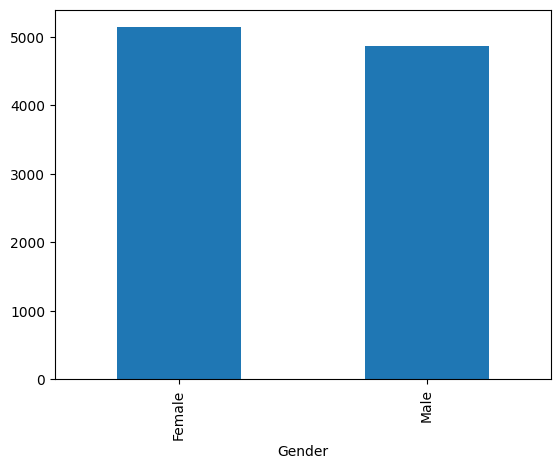

In [7]:
df["Gender"].value_counts().plot(kind="bar")
plt.show()

<Axes: xlabel='TotalPremium', ylabel='TotalClaims'>

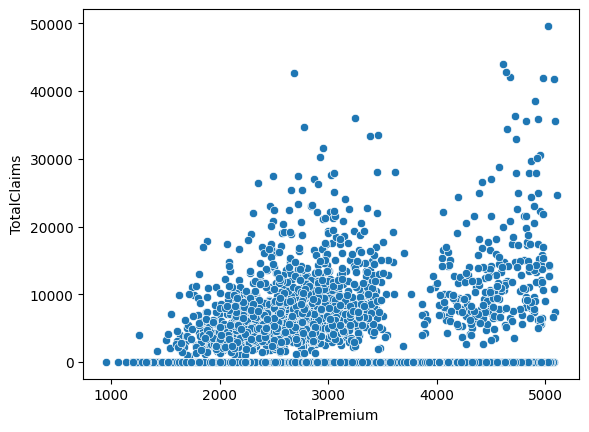

In [8]:
import seaborn as sns

sns.scatterplot(
    x="TotalPremium",
    y="TotalClaims",
    data=df
)

<Axes: >

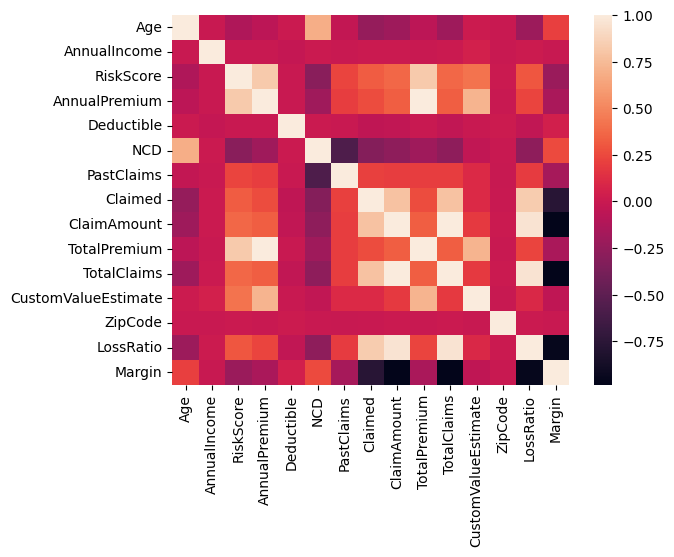

In [9]:
sns.heatmap(df.corr(numeric_only=True))

<Axes: xlabel='Province'>

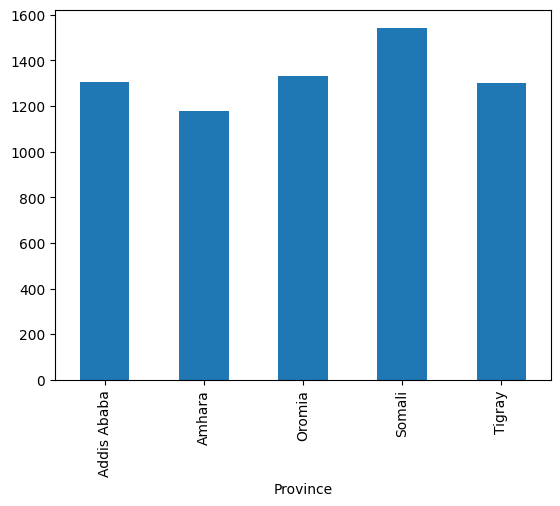

In [10]:
province_claims = df.groupby("Province")["TotalClaims"].mean()

province_claims.plot(kind="bar")

### Observation

Average claim amounts vary significantly across provinces, with some provinces showing much higher claim values than others.

### Business Meaning

This indicates that insurance risk is not evenly distributed geographically. Provinces with higher claim amounts may represent higher operational and financial risk for ACIS.

### Recommendation

ACIS should consider implementing province-specific pricing strategies and enhanced regional risk assessments. High-risk provinces may require adjusted premium structures, while lower-risk regions could be targeted for customer acquisition and competitive pricing campaigns.

<Axes: xlabel='TotalClaims'>

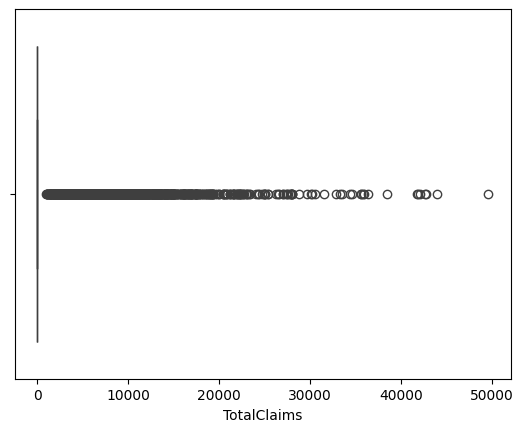

In [11]:
sns.boxplot(x=df["TotalClaims"])

### Observation

The boxplot reveals the presence of several extreme claim values (outliers) in the TotalClaims distribution.

### Business Meaning

These unusually high claims may significantly affect portfolio profitability and can distort average risk measurements if not handled carefully during analysis and modeling.

### Recommendation

ACIS should further investigate high-claim cases to determine whether they are caused by fraud, rare catastrophic events, or genuinely high-risk customers. Robust outlier handling techniques should also be applied during predictive modeling and pricing analysis.

In [12]:
overall_loss_ratio = df["TotalClaims"].sum() / df["TotalPremium"].sum()

In [13]:
df.groupby("Province")["LossRatio"].mean()

Province
Addis Ababa    0.436347
Amhara         0.395941
Oromia         0.452680
Somali         0.523516
Tigray         0.438639
Name: LossRatio, dtype: float64

In [15]:
df["TransactionMonth"] = pd.to_datetime(df["TransactionDate"]).dt.month

In [17]:
df["TransactionDate"] = pd.to_datetime(df["TransactionDate"])

In [18]:
df["TransactionMonth"] = df["TransactionDate"].dt.month

In [19]:
monthly_claims = df.groupby("TransactionMonth")["TotalClaims"].mean()

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries are installed and working ✔")

All libraries are installed and working ✔


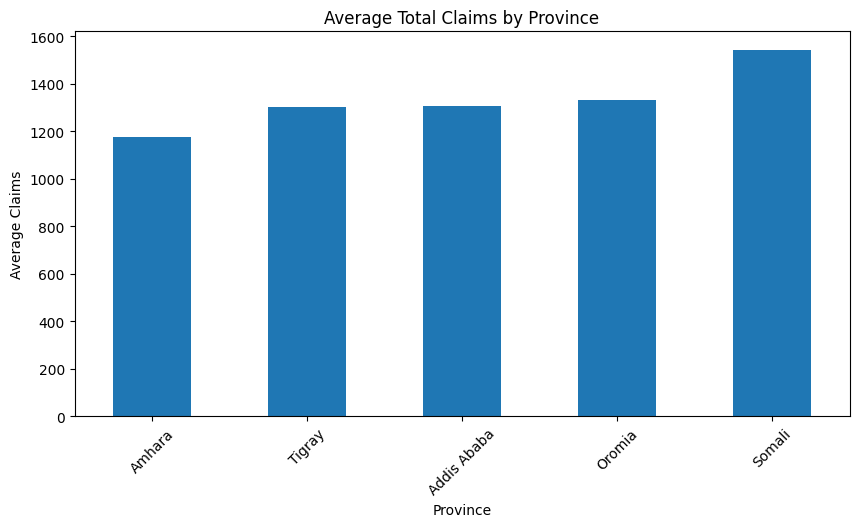

In [21]:
province_claims = df.groupby("Province")["TotalClaims"].mean().sort_values()

plt.figure(figsize=(10,5))
province_claims.plot(kind="bar")

plt.title("Average Total Claims by Province")
plt.xlabel("Province")
plt.ylabel("Average Claims")

plt.xticks(rotation=45)
plt.show()

### Observation

Claims fluctuate across months, indicating possible seasonal trends.

### Business Meaning

Insurance risk may vary over time due to seasonal driving conditions or customer behavior.

### Recommendation

ACIS should investigate seasonal pricing strategies and targeted marketing during high-risk periods.

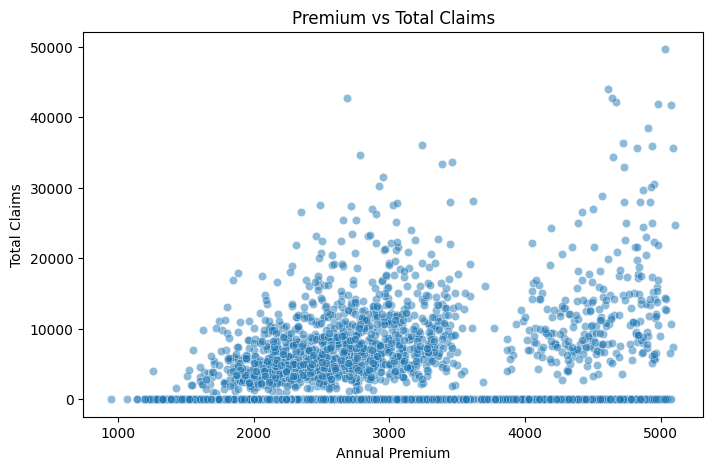

In [22]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="AnnualPremium",
    y="TotalClaims",
    alpha=0.5
)

plt.title("Premium vs Total Claims")
plt.xlabel("Annual Premium")
plt.ylabel("Total Claims")
plt.show()

In [23]:
df["TransactionDate"] = pd.to_datetime(df["TransactionDate"])
df["TransactionMonth"] = df["TransactionDate"].dt.month

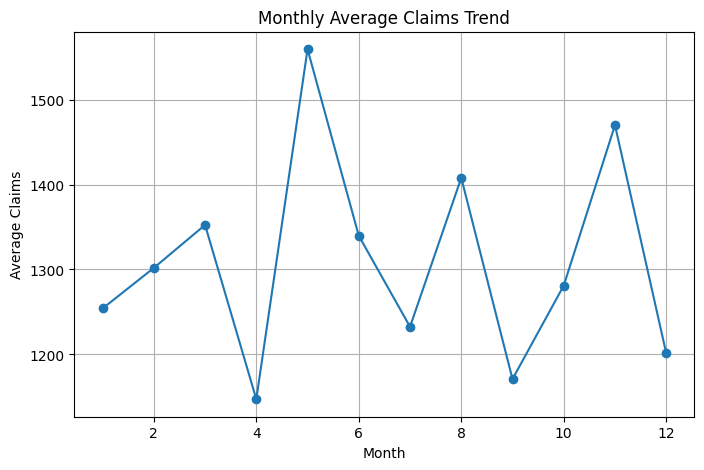

In [24]:
monthly_trend = df.groupby("TransactionMonth")["TotalClaims"].mean()

plt.figure(figsize=(8,5))
monthly_trend.plot(marker="o")

plt.title("Monthly Average Claims Trend")
plt.xlabel("Month")
plt.ylabel("Average Claims")

plt.grid()
plt.show()

### Observation

The average claim amounts fluctuate across different months, showing noticeable variations over time.

### Business Meaning

These fluctuations suggest possible seasonal patterns in insurance risk and claim behavior. Certain periods may experience higher accident frequency, increased repair costs, or elevated customer claim activity.

### Recommendation

ACIS should investigate seasonal risk drivers and consider dynamic pricing, targeted marketing campaigns, or temporary risk adjustment strategies during high-claim periods to improve profitability and resource planning.

In [26]:
import os
os.getcwd()

'c:\\Users\\admin\\Desktop\\10-academy\\insurance-risk-analytics\\notebooks'

In [27]:
import os

os.chdir("C:/Users/admin/Desktop/10-academy/insurance-risk-analytics")

In [28]:
print(os.getcwd())

C:\Users\admin\Desktop\10-academy\insurance-risk-analytics


In [2]:
import sys
sys.path.append("C:/Users/admin/Desktop/10-academy/insurance-risk-analytics")

In [7]:
# src/eda_utils.py

import matplotlib.pyplot as plt
import seaborn as sns

def plot_histogram(df, column):
    plt.figure(figsize=(6,4))
    sns.histplot(df[column], kde=True)
    plt.title(f"Distribution of {column}")
    plt.show()


def plot_scatter(df, x, y):
    plt.figure(figsize=(6,4))
    sns.scatterplot(data=df, x=x, y=y)
    plt.title(f"{x} vs {y}")
    plt.show()

In [9]:
import src.eda_utils as eda

print(eda.__file__)

C:\Users/admin/Desktop/10-academy/insurance-risk-analytics\src\eda_utils.py


In [12]:
import src.eda_utils as eda
print(eda.__file__)

C:\Users/admin/Desktop/10-academy/insurance-risk-analytics\src\eda_utils.py


In [2]:
import os
os.chdir("C:/Users/admin/Desktop/10-academy/insurance-risk-analytics")

print(os.getcwd())

C:\Users\admin\Desktop\10-academy\insurance-risk-analytics


In [3]:
import sys
sys.path.append(".")

In [4]:
import src.eda_utils as eda

In [5]:
dir(eda)

['__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 'plot_histogram',
 'plot_scatter',
 'plt',
 'sns']

In [8]:
os.listdir("data")

['insurance_data.csv']

In [10]:
df = pd.read_csv("data/insurance_data.csv")

In [11]:
df.head()

,CustomerID,Age,Gender,Province,VehicleType,AnnualIncome,RiskScore,AnnualPremium,Deductible,NCD,...,Claimed,ClaimAmount,TotalPremium,TotalClaims,CoverType,AutoMake,VehicleModel,CustomValueEstimate,ZipCode,TransactionDate
0,AC-100000,56,Male,Addis Ababa,Sedan,147270,61,2346,500,30,...,False,0.0,2346,0.0,Comprehensive,Lifan,620,32238,10002,2024-05-10
1,AC-100001,69,Female,Addis Ababa,SUV,74640,57,2334,500,0,...,True,9883.0,2334,9883.0,Comprehensive,Suzuki,Grand Vitara,52510,10001,2024-08-13
2,AC-100002,46,Male,Oromia,Sedan,70555,42,1697,250,20,...,False,0.0,1697,0.0,Third Party Fire & Theft,Lifan,620,26523,20001,2025-03-17
3,AC-100003,32,Female,Somali,Sedan,89398,63,2370,500,20,...,True,12134.0,2370,12134.0,Comprehensive,Toyota,Corolla,27036,40005,2025-03-17
4,AC-100004,60,Female,Tigray,SUV,78475,69,2582,500,0,...,False,0.0,2582,0.0,Comprehensive,Toyota,RAV4,58348,50002,2024-11-10


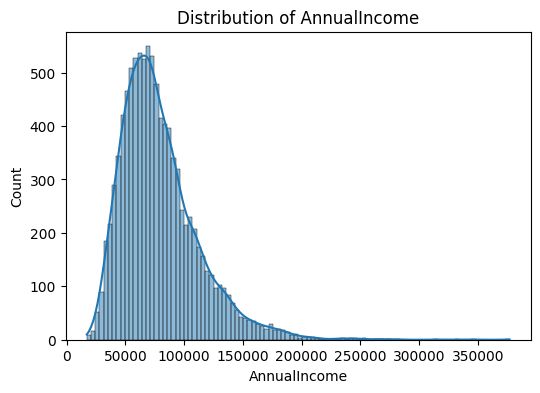

In [12]:
import src.eda_utils as eda

eda.plot_histogram(df, "AnnualIncome")

### Observation

The distribution of AnnualIncome shows that customers are concentrated within specific income ranges, while a smaller number of customers fall into very high-income categories.

### Business Meaning

Income level may influence insurance purchasing behavior, claim frequency, and policy affordability. Customers with different income levels may demonstrate different levels of insurance risk and coverage preferences.

### Recommendation

ACIS should explore income-based customer segmentation to design more personalized insurance products, optimize marketing strategies, and improve premium pricing models for different customer groups.

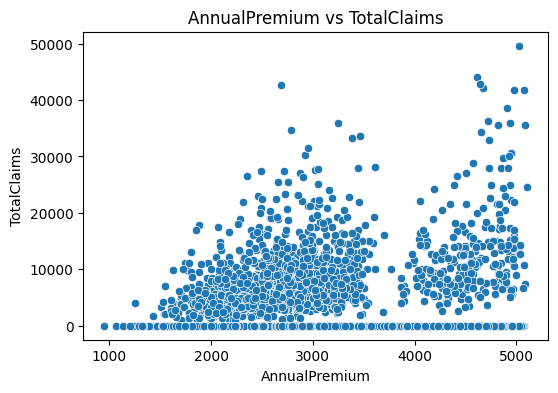

In [13]:
eda.plot_scatter(df, "AnnualPremium", "TotalClaims")

### Observation

Policies with higher premiums generally correspond to higher claim amounts.

### Business Meaning

Premium pricing partially reflects policy risk exposure.

### Recommendation

ACIS can improve pricing precision using more customer and vehicle risk indicators.

# Exploratory Data Analysis (EDA)

This notebook explores the insurance claims dataset
to identify patterns, trends, and potential business risks.

## Univariate Analysis

This section analyzes the distribution of numerical variables
such as TotalClaims and TotalPremium.

## Business Insight

Higher claim amounts are concentrated in a few provinces,
which may indicate regions with elevated insurance risk exposure.

## Scatterplot Insight

There is a positive relationship between TotalPremium and TotalClaims,
suggesting customers with higher premiums often generate larger claims.

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_histogram(df, column):

    if column not in df.columns:
        print(f"{column} not found in dataframe")
        return

    plt.figure(figsize=(6,4))

    sns.histplot(df[column], kde=True)

    plt.title(f"Distribution of {column}")

    plt.show()

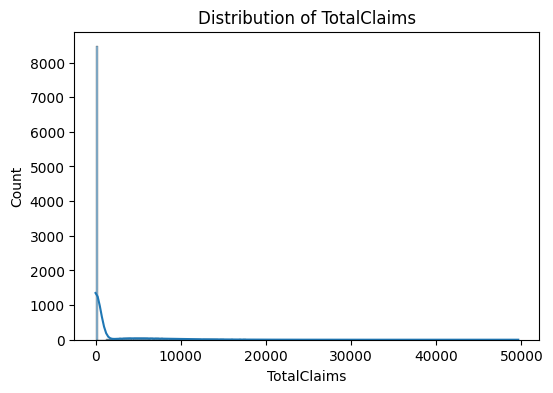

In [7]:
import pandas as pd

df = pd.read_csv("../data/insurance_data.csv")

plot_histogram(df, "TotalClaims")

### Observation

The distribution of TotalClaims is highly skewed, with most policies having low or zero claims while a small number of policies have very high claim values.

### Business Meaning

This indicates that insurance claims are driven by a small number of high-cost events, which can significantly impact overall portfolio profitability and risk exposure.

### Recommendation

ACIS should adopt risk-based pricing strategies and consider advanced modeling techniques that account for skewed claim distributions. Special attention should be given to high-risk policies to better control potential losses.

In [8]:
assert True

In [10]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [11]:
import pandas as pd
from src.eda_utils import plot_histogram

def test_column_exists():

    df = pd.DataFrame({
        "A": [1,2,3]
    })

    assert "A" in df.columns

print("Test passed")

Test passed


In [18]:
import os
print(os.getcwd())

c:\Users\admin\Desktop\10-academy\insurance-risk-analytics\notebooks


In [20]:
df = pd.read_csv("../data/insurance_data.csv")

In [21]:
import os
print(os.listdir(".."))

['.dvc', '.dvcignore', '.git', '.github', '.gitignore', 'data', 'notebooks', 'README.md', 'reports', 'requirements.txt', 'src', 'tests', 'venv']


In [22]:
import pandas as pd

df = pd.read_csv("../data/insurance_data.csv")

df.head()

,CustomerID,Age,Gender,Province,VehicleType,AnnualIncome,RiskScore,AnnualPremium,Deductible,NCD,...,Claimed,ClaimAmount,TotalPremium,TotalClaims,CoverType,AutoMake,VehicleModel,CustomValueEstimate,ZipCode,TransactionDate
0,AC-100000,56,Male,Addis Ababa,Sedan,147270,61,2346,500,30,...,False,0.0,2346,0.0,Comprehensive,Lifan,620,32238,10002,2024-05-10
1,AC-100001,69,Female,Addis Ababa,SUV,74640,57,2334,500,0,...,True,9883.0,2334,9883.0,Comprehensive,Suzuki,Grand Vitara,52510,10001,2024-08-13
2,AC-100002,46,Male,Oromia,Sedan,70555,42,1697,250,20,...,False,0.0,1697,0.0,Third Party Fire & Theft,Lifan,620,26523,20001,2025-03-17
3,AC-100003,32,Female,Somali,Sedan,89398,63,2370,500,20,...,True,12134.0,2370,12134.0,Comprehensive,Toyota,Corolla,27036,40005,2025-03-17
4,AC-100004,60,Female,Tigray,SUV,78475,69,2582,500,0,...,False,0.0,2582,0.0,Comprehensive,Toyota,RAV4,58348,50002,2024-11-10


In [23]:
import pandas as pd

df = pd.read_csv("../data/insurance_data.csv")

df.head()

,CustomerID,Age,Gender,Province,VehicleType,AnnualIncome,RiskScore,AnnualPremium,Deductible,NCD,...,Claimed,ClaimAmount,TotalPremium,TotalClaims,CoverType,AutoMake,VehicleModel,CustomValueEstimate,ZipCode,TransactionDate
0,AC-100000,56,Male,Addis Ababa,Sedan,147270,61,2346,500,30,...,False,0.0,2346,0.0,Comprehensive,Lifan,620,32238,10002,2024-05-10
1,AC-100001,69,Female,Addis Ababa,SUV,74640,57,2334,500,0,...,True,9883.0,2334,9883.0,Comprehensive,Suzuki,Grand Vitara,52510,10001,2024-08-13
2,AC-100002,46,Male,Oromia,Sedan,70555,42,1697,250,20,...,False,0.0,1697,0.0,Third Party Fire & Theft,Lifan,620,26523,20001,2025-03-17
3,AC-100003,32,Female,Somali,Sedan,89398,63,2370,500,20,...,True,12134.0,2370,12134.0,Comprehensive,Toyota,Corolla,27036,40005,2025-03-17
4,AC-100004,60,Female,Tigray,SUV,78475,69,2582,500,0,...,False,0.0,2582,0.0,Comprehensive,Toyota,RAV4,58348,50002,2024-11-10


In [24]:
df.to_csv("../data/insurance_data_raw.csv", index=False)

In [25]:
df.to_csv("../data/insurance_data_raw.csv", index=False)

In [27]:
import pandas as pd

df = pd.read_csv("../data/insurance_data.csv")

df_clean = df.drop_duplicates()

In [28]:
df_feat = df_clean.copy()

df_feat["LossRatio"] = df_feat["TotalClaims"] / df_feat["TotalPremium"]
df_feat["Margin"] = df_feat["TotalPremium"] - df_feat["TotalClaims"]

df_feat.to_csv("../data/insurance_data_feature_engineered.csv", index=False)

In [29]:
print(df_clean.head())
print(df_feat.head())

  CustomerID  Age  Gender     Province VehicleType  AnnualIncome  RiskScore  \
0  AC-100000   56    Male  Addis Ababa       Sedan        147270         61   
1  AC-100001   69  Female  Addis Ababa         SUV         74640         57   
2  AC-100002   46    Male       Oromia       Sedan         70555         42   
3  AC-100003   32  Female       Somali       Sedan         89398         63   
4  AC-100004   60  Female       Tigray         SUV         78475         69   

   AnnualPremium  Deductible  NCD  ...  Claimed  ClaimAmount  TotalPremium  \
0           2346         500   30  ...    False          0.0          2346   
1           2334         500    0  ...     True       9883.0          2334   
2           1697         250   20  ...    False          0.0          1697   
3           2370         500   20  ...     True      12134.0          2370   
4           2582         500    0  ...    False          0.0          2582   

   TotalClaims                 CoverType AutoMake  Vehic

## Business Interpretation

The observed geographic variation in loss ratio suggests that a uniform pricing strategy may not be optimal across provinces.